Table 1 on the next page contains data on the number of airline miles flown in the
United Kingdom. For the following tasks use Python and submit one .ipynb file incorporating
all your answers.

#A) Create a .csv file out of the given data and put it online (you will use a link to it in yourprogram).


In [137]:
import pandas as pd

# Создаем DataFrame из данных
data = {
    'Month': ['Jan-1964', 'Feb-1964', 'Mar-1964', 'Apr-1964', 'May-1964', 'Jun-1964', 'Jul-1964', 'Aug-1964', 'Sep-1964', 'Oct-1964', 'Nov-1964', 'Dec-1964',
              'Jan-1965', 'Feb-1965', 'Mar-1965', 'Apr-1965', 'May-1965', 'Jun-1965', 'Jul-1965', 'Aug-1965', 'Sep-1965', 'Oct-1965', 'Nov-1965', 'Dec-1965',
              'Jan-1966', 'Feb-1966', 'Mar-1966', 'Apr-1966', 'May-1966', 'Jun-1966', 'Jul-1966', 'Aug-1966', 'Sep-1966', 'Oct-1966', 'Nov-1966', 'Dec-1966',
              'Jan-1967', 'Feb-1967', 'Mar-1967', 'Apr-1967', 'May-1967', 'Jun-1967', 'Jul-1967', 'Aug-1967', 'Sep-1967', 'Oct-1967', 'Nov-1967', 'Dec-1967',
              'Jan-1968', 'Feb-1968', 'Mar-1968', 'Apr-1968', 'May-1968', 'Jun-1968', 'Jul-1968', 'Aug-1968', 'Sep-1968', 'Oct-1968', 'Nov-1968', 'Dec-1968',
              'Jan-1969', 'Feb-1969', 'Mar-1969', 'Apr-1969', 'May-1969', 'Jun-1969', 'Jul-1969', 'Aug-1969', 'Sep-1969', 'Oct-1969', 'Nov-1969', 'Dec-1969',
              'Jan-1970', 'Feb-1970', 'Mar-1970', 'Apr-1970', 'May-1970', 'Jun-1970', 'Jul-1970', 'Aug-1970', 'Sep-1970', 'Oct-1970', 'Nov-1970', 'Dec-1970'],
    'Miles (In Millions)': [7.269, 6.775, 7.819, 8.371, 9.069, 10.248, 11.030, 10.882, 10.333, 9.109, 7.685, 7.682,
                             8.350, 7.829, 8.829, 9.948, 10.638, 11.253, 11.424, 11.391, 10.665, 9.396, 7.775, 7.933,
                             8.186, 7.444, 8.484, 9.864, 10.252, 12.282, 11.637, 11.577, 12.417, 9.637, 8.094, 9.280,
                             8.334, 7.899, 9.994, 10.078, 10.801, 12.953, 12.222, 12.246, 13.281, 10.366, 8.730, 9.614,
                             8.639, 8.772, 10.894, 10.455, 11.179, 10.588, 10.794, 12.770, 13.812, 10.857, 9.290, 10.925,
                             9.491, 8.919, 11.607, 8.852, 12.537, 14.759, 13.667, 13.731, 15.110, 12.185, 10.645, 12.161,
                             10.840, 10.436, 13.589, 13.402, 13.103, 14.933, 14.147, 14.057, 16.234, 12.389, 11.594, 12.772]
}

df = pd.DataFrame(data)
print(len(df['Month']))
# Сохраняем DataFrame в файл CSV
df.to_csv('miles_data.csv', index=False)


84


In [138]:
import gdown



url = 'https://drive.google.com/uc?id=1tPD9c9u6vAd2G063kiJmJaHLw7eNY1XA'


output = 'miles_data.csv'


gdown.download(url, output, quiet=False)


df = pd.read_csv(output)
print(df.head())


Downloading...
From: https://drive.google.com/uc?id=1tPD9c9u6vAd2G063kiJmJaHLw7eNY1XA
To: /content/miles_data.csv
100%|██████████| 1.33k/1.33k [00:00<00:00, 2.14MB/s]

      Month  Miles (In Millions)
0  Jan-1964                7.269
1  Feb-1964                6.775
2  Mar-1964                7.819
3  Apr-1964                8.371
4  May-1964                9.069


# B) Create a time series plot to visualise the data.

In [139]:
#Переведу данные о дате в стандарт datetime
df['Month'] = pd.to_datetime(df['Month'], format='%b-%Y')
print(df)

        Month  Miles (In Millions)
0  1964-01-01                7.269
1  1964-02-01                6.775
2  1964-03-01                7.819
3  1964-04-01                8.371
4  1964-05-01                9.069
..        ...                  ...
79 1970-08-01               14.057
80 1970-09-01               16.234
81 1970-10-01               12.389
82 1970-11-01               11.594
83 1970-12-01               12.772

[84 rows x 2 columns]


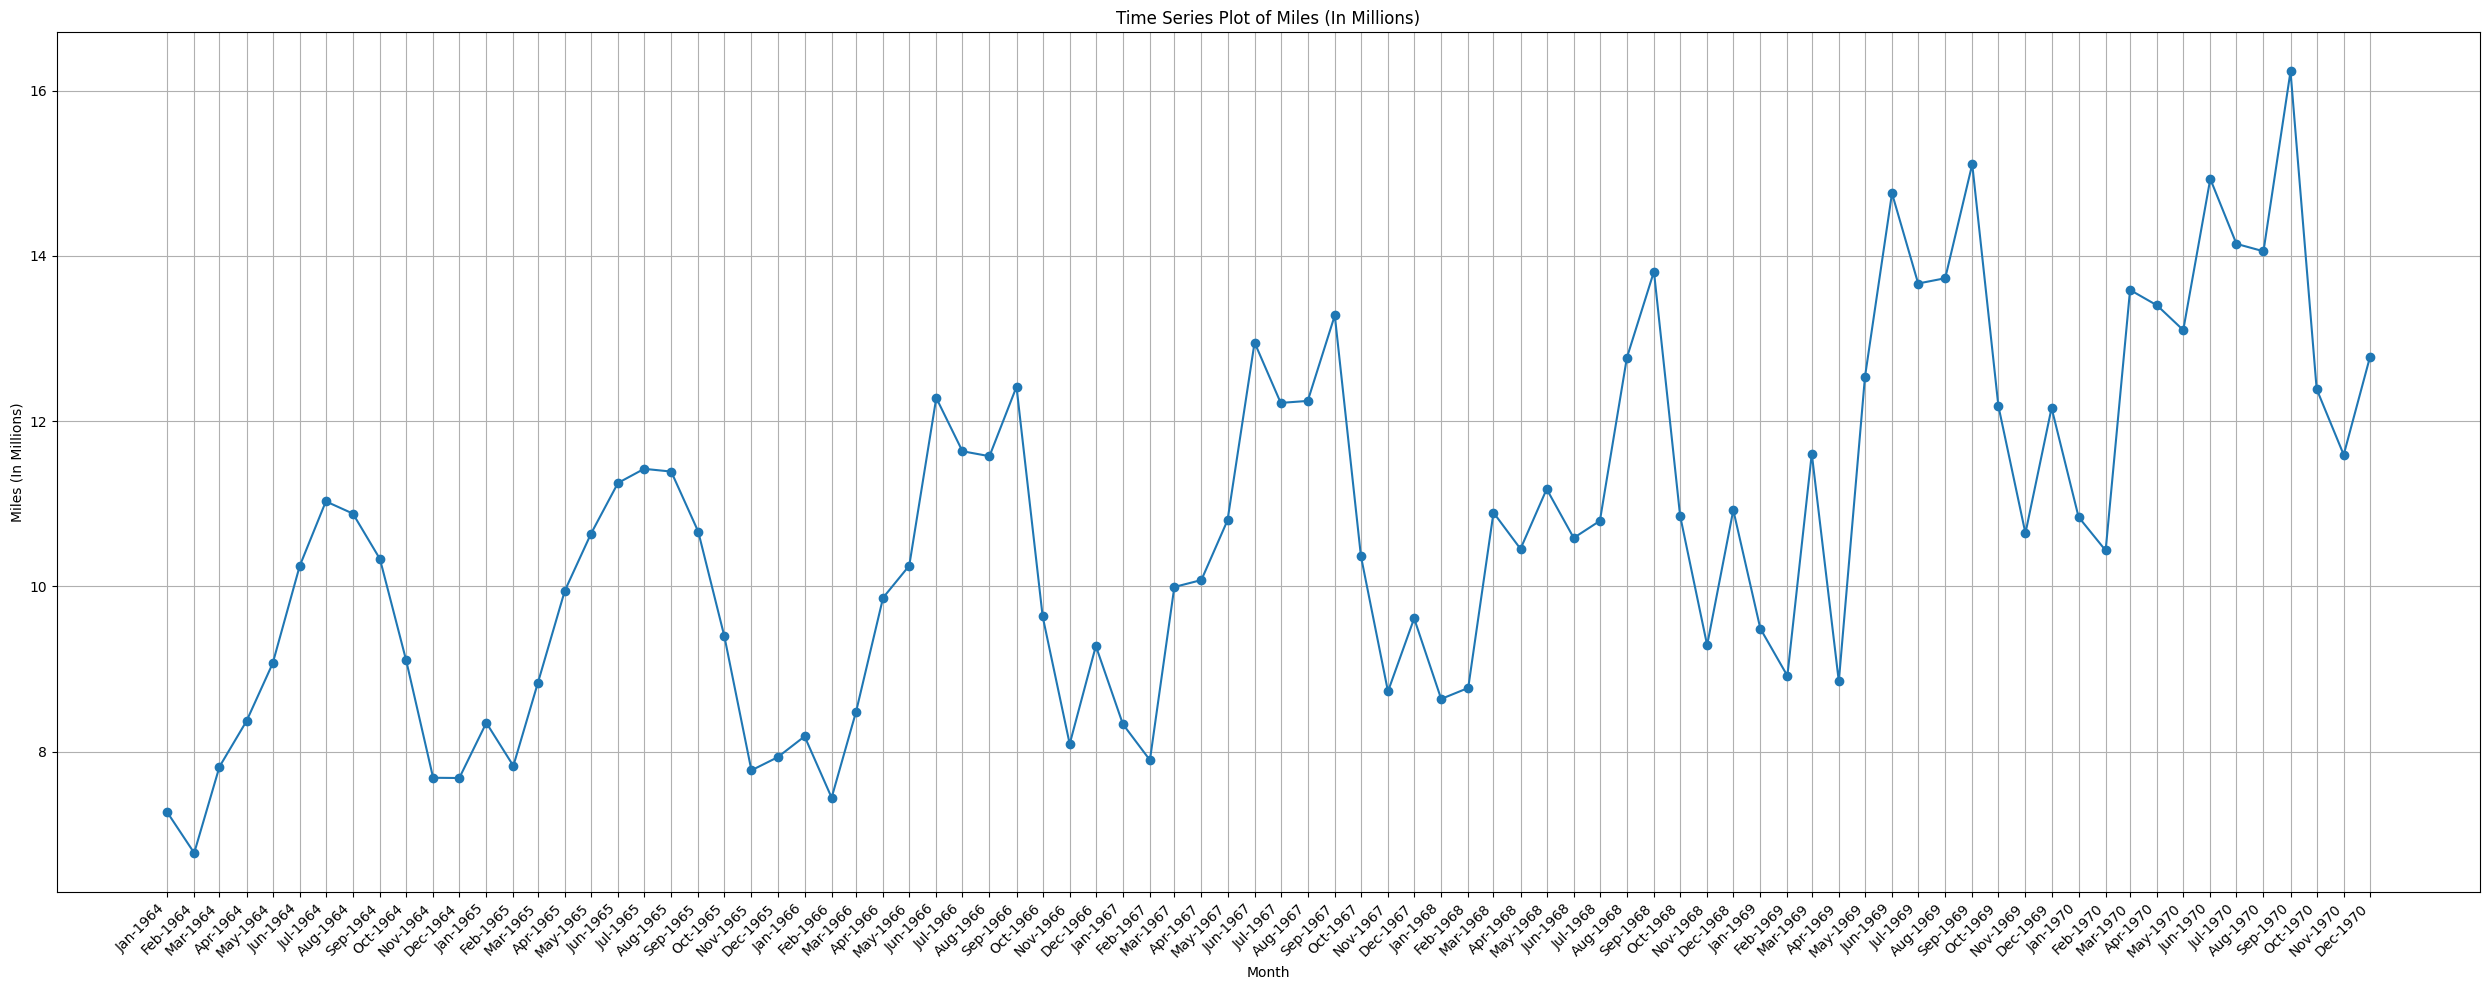

In [140]:
import matplotlib.pyplot as plt

plt.figure(figsize=(25, 10))
plt.plot(df['Month'], df['Miles (In Millions)'], marker='o', linestyle='-')
plt.title('Time Series Plot of Miles (In Millions)')
plt.xlabel('Month')
plt.ylabel('Miles (In Millions)')
plt.grid(True)
plt.xticks(df['Month'], df['Month'].dt.strftime('%b-%Y'), rotation=45, ha='right')
plt.tight_layout()
plt.show()


# C) Decompose the time series into three components (trend, seasonal and residuals). Present
the decomposition together with the observed data in the same figure. What conclusions
can you make about the time series by looking at the graphs?

0      7.269
1      6.775
2      7.819
3      8.371
4      9.069
       ...  
79    14.057
80    16.234
81    12.389
82    11.594
83    12.772
Name: Miles (In Millions), Length: 84, dtype: float64


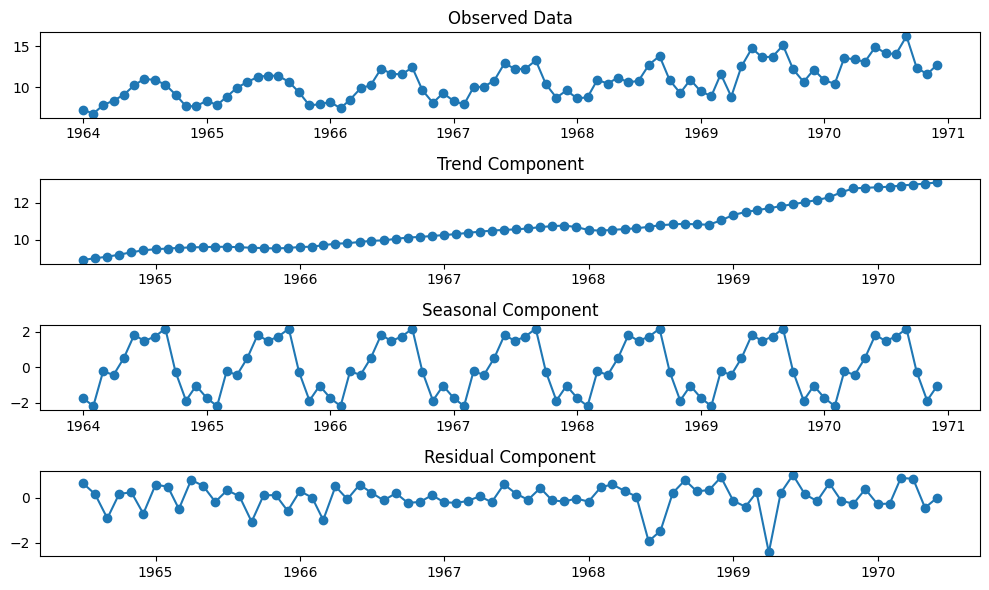

In [141]:
from statsmodels.tsa.seasonal import seasonal_decompose

print(df['Miles (In Millions)'])
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# Perform seasonal decomposition
result = seasonal_decompose(df['Miles (In Millions)'], model='additive')

# Наши данные
plt.figure(figsize=(10, 6))
plt.subplot(4, 1, 1)
plt.plot(df.index, df['Miles (In Millions)'], marker='o', linestyle='-')
plt.title('Observed Data')




# график для анализа трендов
'''
График тренда показывает общий наклон временного ряда, отражая общие долгосрочные изменения или тенденции.
Это график, который показывает, как меняется среднее значение ряда с течением времени, игнорируя сезонные
 и случайные колебания.

✦ The trend is the slow-moving changes in a time series.
✦ Think of it as a line through most of the data points to show the
general direction of a time series

'''
plt.subplot(4, 1, 2)
plt.plot(result.trend.index, result.trend, marker='o', linestyle='-')
plt.title('Trend Component')




#график для анализа сезонности
'''
Сезонная компонента показывает периодические колебания, которые происходят в течение одного
 периода сезона (например, каждый месяц, каждый квартал или каждый год),
 игнорируя общие долгосрочные изменения (тренд) и случайные флуктуации (остатки).


 ✦ The seasonal component captures the seasonal variation, which
is a cycle that repeatedly occurs over a fixed period of time.
✦ It shows how we deviate from the trend.
'''
plt.subplot(4, 1, 3)
plt.plot(result.seasonal.index, result.seasonal, marker='o', linestyle='-')
plt.title('Seasonal Component')




#график остаточной компоненты(остатка)
'''
Остаточная (residual) компонента в этом случае(ибо у нас нет предсказаний, а есть просто временной ряд) представляет
собой разницу между исходными наблюдаемыми
данными и суммой тренда, сезонной компоненты и шума(в данном случае его нет(смотри запись выше)), которые были выделены из временного ряда.
Она отражает остаточные или необъясненные колебания в данных после удаления тренда и сезонности.

Residues t=Observed t−Trend t−Seasonal t−Noise t
​Observed t - наблюдаемое значение в момент времени t.
Trend t - трендовая составляющая в момент времени t.
Seasonal t - сезонная составляющая в момент времени t.
Noise t - ошибка или шум в момент времени t.



✦ The residuals is what cannot be explained by either the trend or
the seasonal components.
✦ Think of the them as adding the Trend and Seasonal graphs
together and comparing the value at each point in time to the
Observed graph.
✦ Residuals usually correspond to random errors, also termed white
noise — information that we cannot model or predict

'''

plt.subplot(4, 1, 4)
plt.plot(result.resid.index, result.resid, marker='o', linestyle='-')
plt.title('Residual Component')

plt.tight_layout()
plt.show()

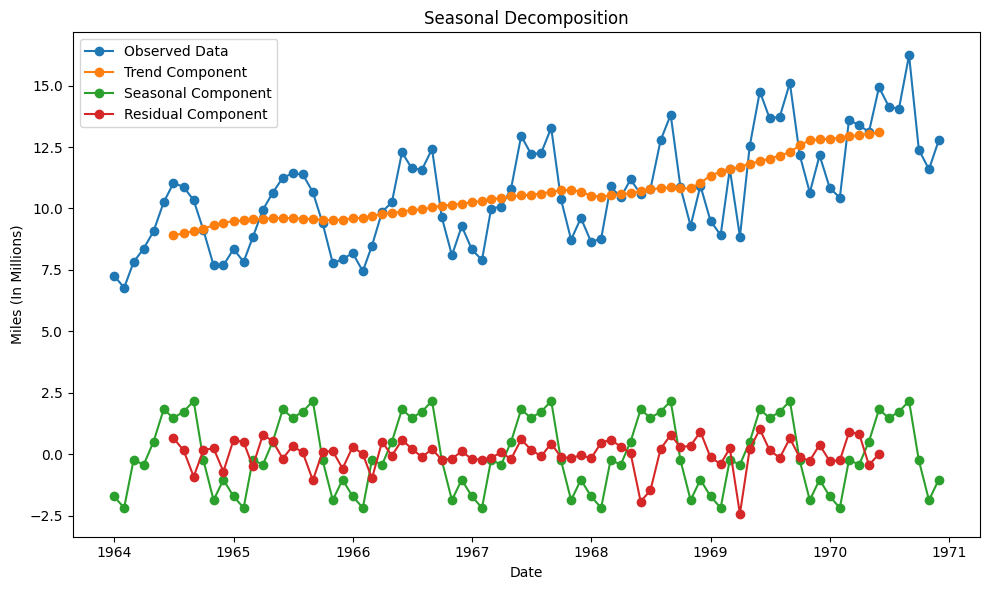

In [165]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# График наблюдаемых данных
plt.plot(df.index, df['Miles (In Millions)'], marker='o', linestyle='-', label='Observed Data')

# График тренда
plt.plot(result.trend.index, result.trend, marker='o', linestyle='-', label='Trend Component')

# График сезонности
plt.plot(result.seasonal.index, result.seasonal, marker='o', linestyle='-', label='Seasonal Component')

# График остаточной компоненты
plt.plot(result.resid.index, result.resid, marker='o', linestyle='-', label='Residual Component')


plt.legend()


plt.xlabel('Date')
plt.ylabel('Miles (In Millions)')
plt.title('Seasonal Decomposition')

# Показываем график
plt.tight_layout()
plt.show()


#**Conclusion:**
##1. Looking at the **Trend graph**, you can see that the number of miles flown is growing every year.
##2.When looking at a **Seasonality graph**, you can notice seasonality (the graph consists of repeating patterns). Let's return to the graph from task B to take a closer look at the seasonality details: the peak occurs during the period from July to October, and in the next month, if the peak occurs from July to August, then the mileage value does not drop much in the next month, however, an important point: if the peak occurred in September or October, then there is a sharp decline in the number of miles flown per month.In addition, looking at the graph, you can see that there is a seasonal sharp rise in the number of flights in December or January, but it is less than our greatest peak. It is also important to note that around April the number of miles traveled begins to increase. The lowest number of miles treated occurs in March or February.
##3.From the **Residues graph** we conclude that: The graph does not have random fluctuations and seasonality is clearly visible on it, which indicates the presence of seasonality in our time series

# D) Divide the data into a train set and a test set.


In [142]:

train_percentage = 0.8


split_index = int(train_percentage * len(df))

train_data = df['Miles (In Millions)'].iloc[:split_index]
test_data = df['Miles (In Millions)'].iloc[split_index:]


In [143]:
print(len(train_data))
print(len(test_data))

67
17


# E) Implement the four baseline models: historical mean, last year’s mean, last known value
and naive seasonal forecast.

In [150]:
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np

def rolling_forecast(df: np.ndarray, train_len: int, horizon: int,  method: str) -> list:


    if method == 'mean':
        train_mean=np.mean(df)
        train_mean_pred = np.full(horizon, train_mean)
        return train_mean_pred

    elif method == 'last year mean':
      last_year_mean = np.mean(df[-12:])
      return [last_year_mean]*horizon

    elif method=="naive":

      forecast_values = df[-horizon:].values
      return forecast_values


    elif method == 'last':
        print(df)
        pred_last_value = np.full(horizon, df[train_len-1])
        #print(pred_last_value)
        return pred_last_value

print(train_data)


Month
1964-01-01     7.269
1964-02-01     6.775
1964-03-01     7.819
1964-04-01     8.371
1964-05-01     9.069
               ...  
1969-03-01    11.607
1969-04-01     8.852
1969-05-01    12.537
1969-06-01    14.759
1969-07-01    13.667
Name: Miles (In Millions), Length: 67, dtype: float64


In [151]:

pred_values_mean = rolling_forecast(train_data, len(train_data),len(test_data),'mean')

pred_last_year_mean = rolling_forecast(train_data, len(train_data),len(test_data),'last year mean')

pred_last_known = rolling_forecast(train_data, len(train_data),len(test_data),'last')

pred_naive_seasonal= rolling_forecast(train_data, len(train_data),len(test_data),"naive")

Month
1964-01-01     7.269
1964-02-01     6.775
1964-03-01     7.819
1964-04-01     8.371
1964-05-01     9.069
               ...  
1969-03-01    11.607
1969-04-01     8.852
1969-05-01    12.537
1969-06-01    14.759
1969-07-01    13.667
Name: Miles (In Millions), Length: 67, dtype: float64


In [152]:
print(pred_values_mean)
print(pred_last_year_mean)
print(pred_last_known)
print(pred_naive_seasonal)

[10.09226866 10.09226866 10.09226866 10.09226866 10.09226866 10.09226866
 10.09226866 10.09226866 10.09226866 10.09226866 10.09226866 10.09226866
 10.09226866 10.09226866 10.09226866 10.09226866 10.09226866]
[11.457166666666666, 11.457166666666666, 11.457166666666666, 11.457166666666666, 11.457166666666666, 11.457166666666666, 11.457166666666666, 11.457166666666666, 11.457166666666666, 11.457166666666666, 11.457166666666666, 11.457166666666666, 11.457166666666666, 11.457166666666666, 11.457166666666666, 11.457166666666666, 11.457166666666666]
[13.667 13.667 13.667 13.667 13.667 13.667 13.667 13.667 13.667 13.667
 13.667 13.667 13.667 13.667 13.667 13.667 13.667]
[10.894 10.455 11.179 10.588 10.794 12.77  13.812 10.857  9.29  10.925
  9.491  8.919 11.607  8.852 12.537 14.759 13.667]


In [153]:
print(len(pred_values_mean))
print(len(pred_last_year_mean))
print(len(pred_last_known))
print(len(pred_naive_seasonal))

17
17
17
17


#F) Compare these baselines models. Which of them looks more efficient for our time series?

#I will plot my forecasts.

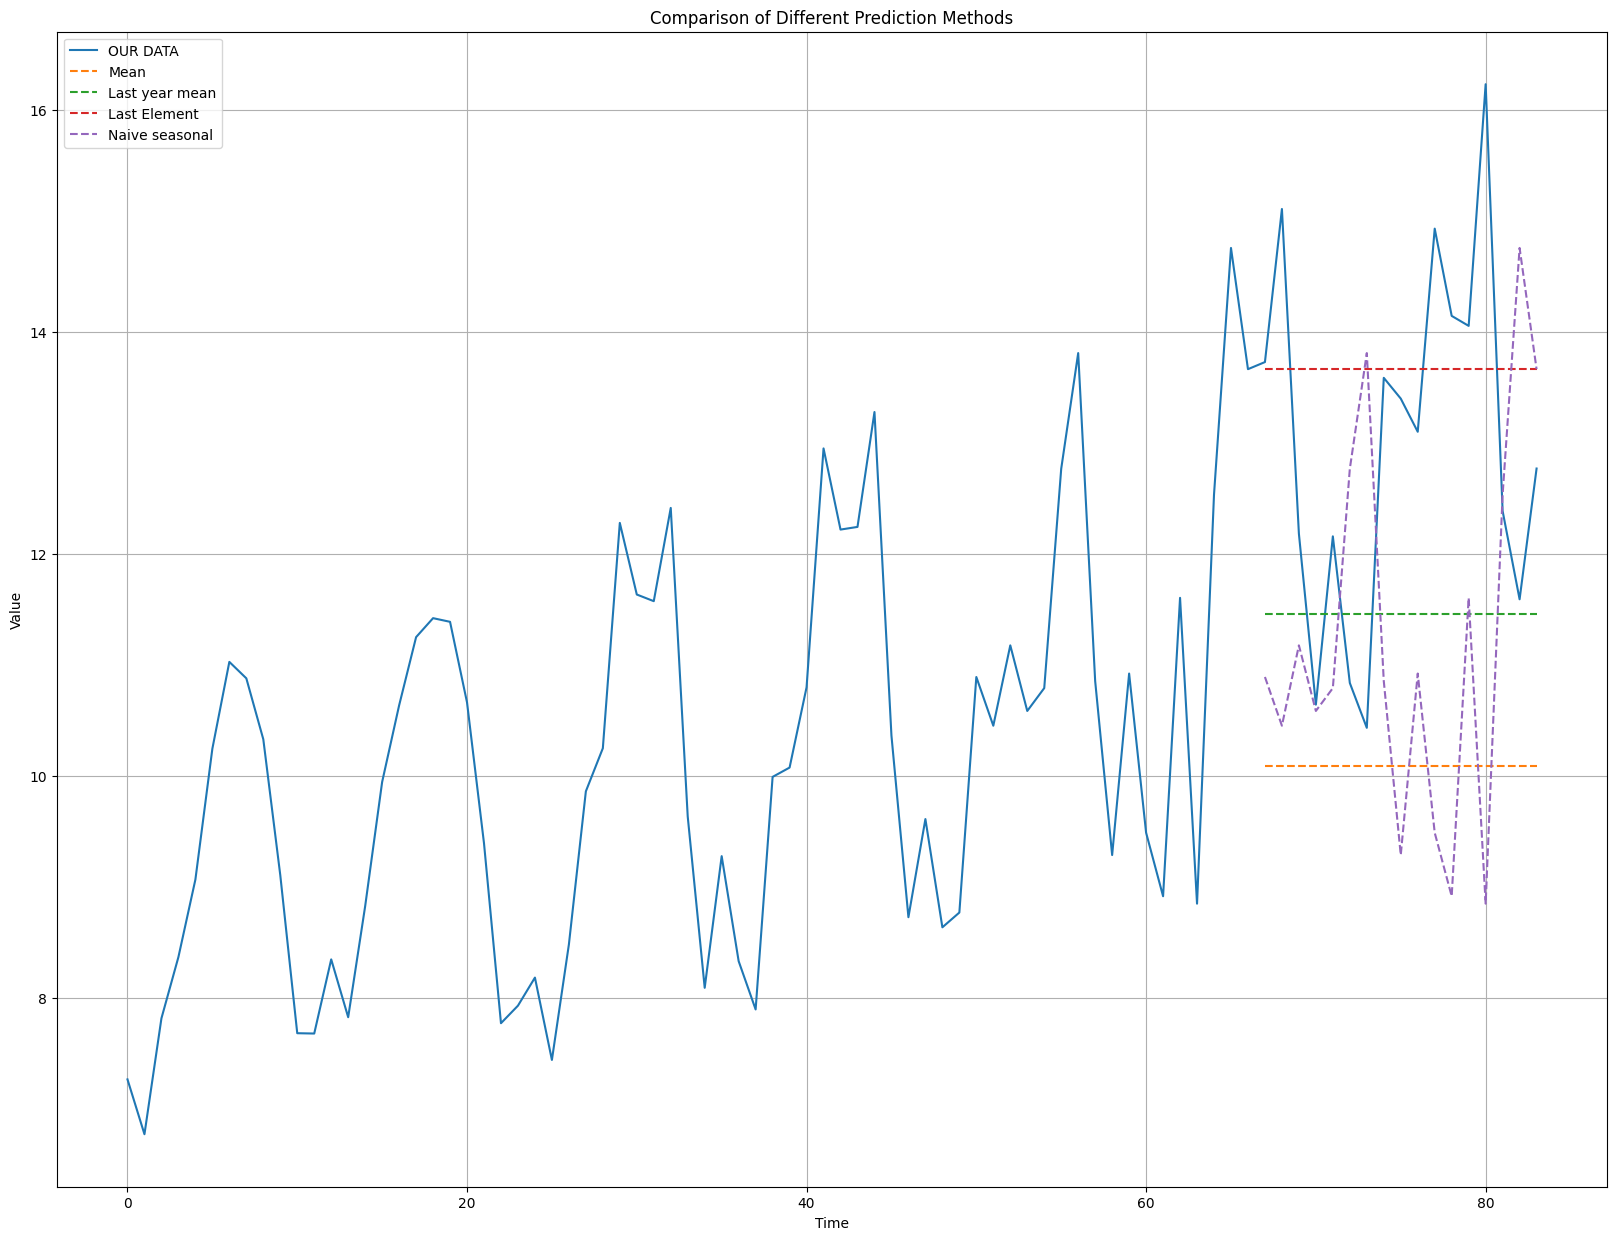

In [157]:
import matplotlib.pyplot as plt


plt.figure(figsize=(20, 15))

plt.plot(np.arange(len(train_data) + len(test_data)), np.concatenate([train_data, test_data]), label='OUR DATA')


plt.plot(np.arange(len(train_data), len(train_data) + len(test_data)), pred_values_mean, label='Mean', linestyle='--')
plt.plot(np.arange(len(train_data), len(train_data) + len(test_data)), pred_last_year_mean, label='Last year mean', linestyle='--')
plt.plot(np.arange(len(train_data), len(train_data) + len(test_data)), pred_last_known, label='Last Element', linestyle='--')

plt.plot(np.arange(len(train_data), len(train_data) + len(test_data)),pred_naive_seasonal, label='Naive seasonal', linestyle='--')


plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Comparison of Different Prediction Methods')
plt.legend()
plt.grid(True)


plt.show()


##Let's check the accuracy of our predictions using MAPE

In [160]:
def mape(y_true, y_pred):
 return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [163]:
print(mape(test_data,pred_values_mean),'%')
print(mape(test_data,pred_last_year_mean),'%')
print(mape(test_data, pred_last_known),'%')
print(mape(test_data,pred_naive_seasonal),'%')

21.310038910286416 %
13.38644618046426 %
11.323955786710544 %
21.227265662169245 %


Let's build a diagram for clarity

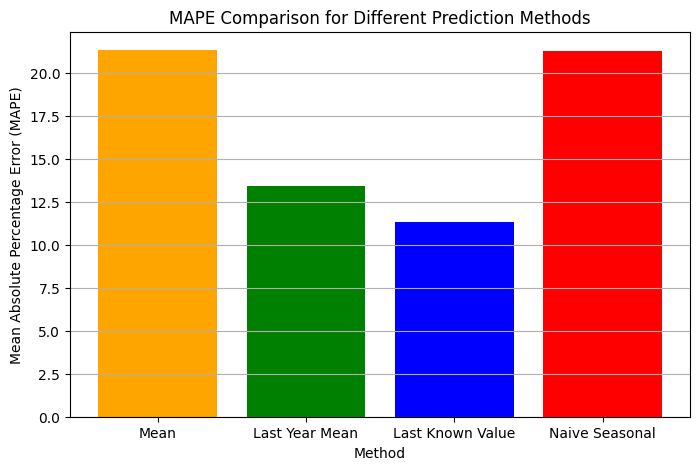

In [162]:
import matplotlib.pyplot as plt


mape_values = [mape(test_data, pred_values_mean),
               mape(test_data, pred_last_year_mean),
               mape(test_data, pred_last_known),
               mape(test_data, pred_naive_seasonal)]


methods = ['Mean', 'Last Year Mean', 'Last Known Value', 'Naive Seasonal']

plt.figure(figsize=(8, 5))
plt.bar(methods, mape_values, color=['orange', 'green', 'blue', 'red'])
plt.xlabel('Method')
plt.ylabel('Mean Absolute Percentage Error (MAPE)')
plt.title('MAPE Comparison for Different Prediction Methods')
plt.grid(axis='y')
plt.show()


#We see that the best method is Last Known Value because it has the smallest MAPE.

Now I want to evaluate the result using MSE to make sure that the conclusions drawn are correct

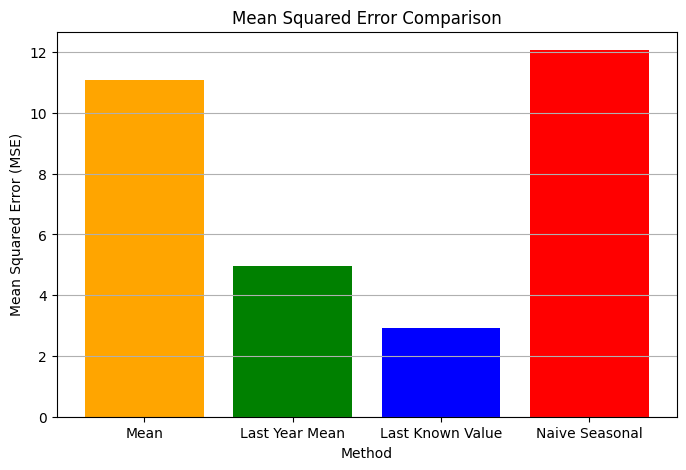

In [158]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Вычисление среднеквадратичной ошибки для каждого метода
mse_mean = mean_squared_error(test_data, pred_values_mean)
mse_last_year_mean = mean_squared_error(test_data, pred_last_year_mean)
mse_last_known = mean_squared_error(test_data, pred_last_known)
mse_naive_seasonal = mean_squared_error(test_data, pred_naive_seasonal)

# Список методов
methods = ['Mean', 'Last Year Mean', 'Last Known Value', 'Naive Seasonal']

# Список среднеквадратичных ошибок
mse_values = [mse_mean, mse_last_year_mean, mse_last_known , mse_naive_seasonal]

plt.figure(figsize=(8, 5))
plt.bar(methods, mse_values, color=['orange', 'green', 'blue', 'red'])
plt.xlabel('Method')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Mean Squared Error Comparison')
plt.grid(axis='y')
plt.show()


#We see that the best method is Last Known Value because it has the smallest MSE.
#The conclusions drawn earlier turned out to be correct!